# **Image Classification with a kNN on CIFAR-10**

In [26]:
%pip install scikit-learn
%pip install keras
%pip install tensorflow
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [13]:
from tensorflow import keras
from sklearn.neighbors import KNeighborsClassifier

In [14]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
y_train, y_test = y_train.ravel(), y_test.ravel()

In [15]:
y_train

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [16]:
# Replace labels with their corresponding class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_train = [class_names[label] for label in y_train]
y_test = [class_names[label] for label in y_test]


In [17]:
y_train

['frog',
 'truck',
 'truck',
 'deer',
 'automobile',
 'automobile',
 'bird',
 'horse',
 'ship',
 'cat',
 'deer',
 'horse',
 'horse',
 'bird',
 'truck',
 'truck',
 'truck',
 'cat',
 'bird',
 'frog',
 'deer',
 'cat',
 'frog',
 'frog',
 'bird',
 'frog',
 'cat',
 'dog',
 'deer',
 'airplane',
 'airplane',
 'truck',
 'automobile',
 'cat',
 'deer',
 'airplane',
 'cat',
 'horse',
 'cat',
 'cat',
 'dog',
 'bird',
 'bird',
 'horse',
 'automobile',
 'automobile',
 'automobile',
 'bird',
 'bird',
 'airplane',
 'truck',
 'dog',
 'horse',
 'truck',
 'bird',
 'bird',
 'dog',
 'bird',
 'deer',
 'cat',
 'automobile',
 'automobile',
 'ship',
 'bird',
 'automobile',
 'automobile',
 'deer',
 'truck',
 'horse',
 'ship',
 'dog',
 'truck',
 'frog',
 'horse',
 'cat',
 'automobile',
 'truck',
 'airplane',
 'cat',
 'automobile',
 'cat',
 'dog',
 'deer',
 'dog',
 'horse',
 'horse',
 'deer',
 'horse',
 'truck',
 'deer',
 'bird',
 'cat',
 'ship',
 'airplane',
 'automobile',
 'frog',
 'automobile',
 'automobile',
 

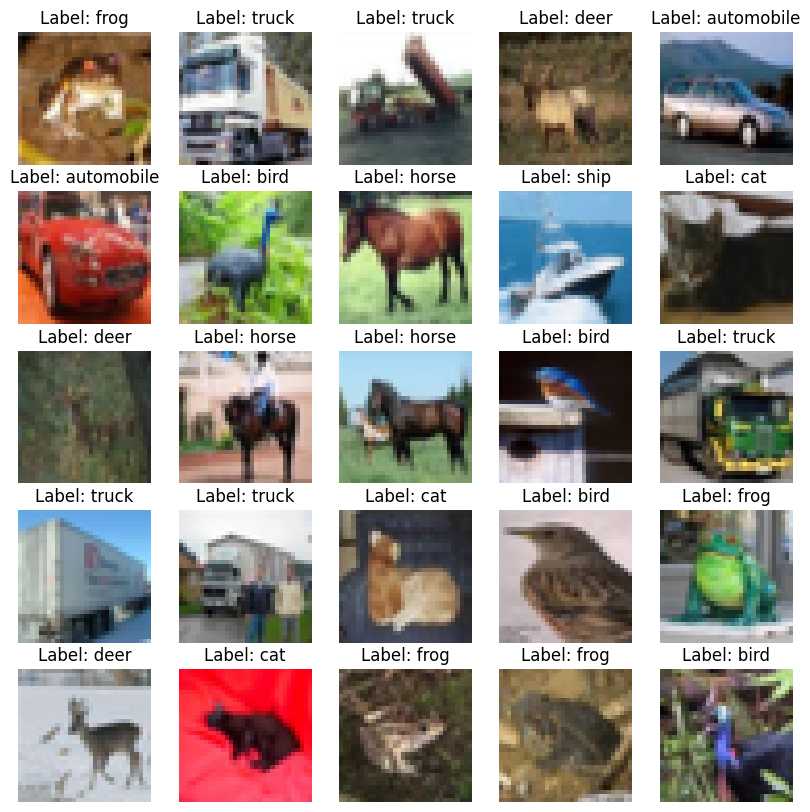

In [18]:
# Visualize some images from the dataset with their corresponding labels
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.show()

In [19]:
# Flatten de cada imagen, conservando el eje de muestras
X_train_flat = X_train.reshape(len(X_train), -1) #
X_test_flat = X_test.reshape(len(X_test), -1)

# Some alternative ways to flatten the images (commented out)
# X_train_flat = np.array([img.flatten() for img in X_train])
# X_test_flat = np.array([img.flatten() for img in X_test])

In [ ]:
# Shape of the flattened train data
print("Shape of X_train_flat:", X_train_flat.shape)

Shape of X_train_flat: (50000, 3072)


In [21]:
# Shapes of the flattened test data 
print("Shape of X_test_flat:", X_test_flat.shape)

Shape of X_test_flat: (10000, 3072)


In [22]:
# Fit a kNN classifier to the training data
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_flat, y_train)

KNeighborsClassifier(n_neighbors=3)

In [23]:
print("Accuracy kNN:", knn.score(X_test_flat, y_test))

Accuracy kNN: 0.3303


In [24]:
# Plot the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = knn.predict(X_test_flat)
cm = confusion_matrix(y_test, y_pred, labels=class_names)
cm

array([[573,   9, 109,  19,  48,   6,  22,   5, 204,   5],
       [196, 243, 125,  61, 113,  29,  37,   6, 168,  22],
       [156,   7, 450,  54, 197,  30,  59,   7,  39,   1],
       [102,  11, 281, 225, 147,  91,  89,  14,  33,   7],
       [104,   5, 291,  55, 436,  21,  36,  12,  40,   0],
       [100,   5, 249, 172, 144, 213,  68,  11,  34,   4],
       [ 49,   5, 327,  89, 252,  27, 229,   2,  20,   0],
       [131,  20, 217,  73, 235,  38,  41, 199,  44,   2],
       [183,  30,  52,  42,  51,  14,   9,   3, 612,   4],
       [193,  87, 128,  76, 110,  27,  43,  13, 200, 123]])

Text(95.72222222222221, 0.5, 'True')

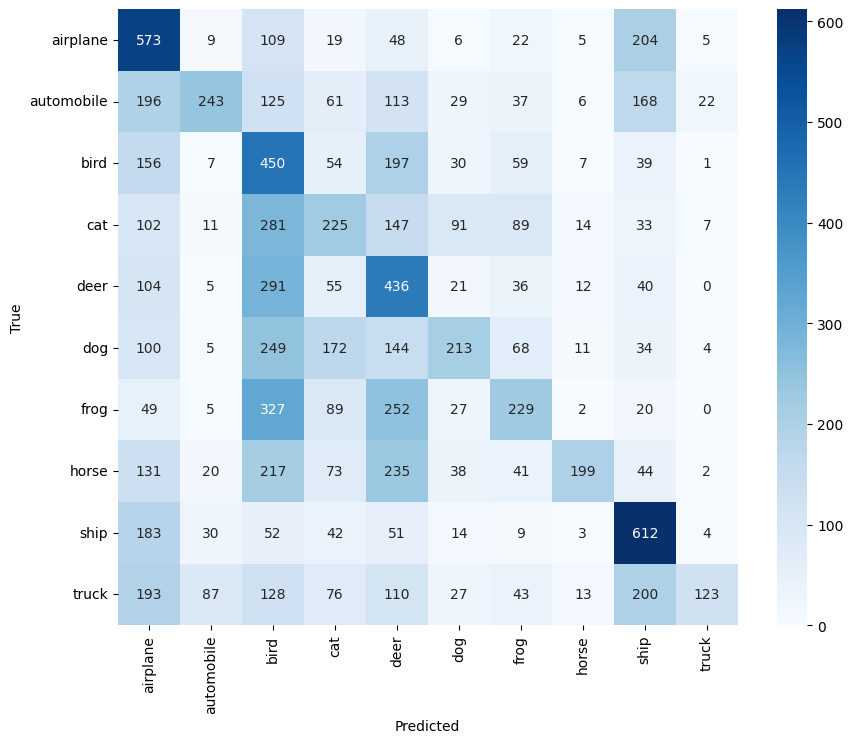

In [ ]:
# Plot the heatmap of the confusion matrix
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_names, yticklabels=class_names, fmt='g') #fmt ='g' to display integer values
plt.xlabel('Predicted')
plt.ylabel('True')

In [29]:
# Plot the classification report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.32      0.57      0.41      1000
  automobile       0.58      0.24      0.34      1000
        bird       0.20      0.45      0.28      1000
         cat       0.26      0.23      0.24      1000
        deer       0.25      0.44      0.32      1000
         dog       0.43      0.21      0.28      1000
        frog       0.36      0.23      0.28      1000
       horse       0.73      0.20      0.31      1000
        ship       0.44      0.61      0.51      1000
       truck       0.73      0.12      0.21      1000

    accuracy                           0.33     10000
   macro avg       0.43      0.33      0.32     10000
weighted avg       0.43      0.33      0.32     10000

